
Random_state:  38
              precision    recall  f1-score   support

        Heal       1.00      0.78      0.88         9
         Not       0.78      1.00      0.88         7

    accuracy                           0.88        16
   macro avg       0.89      0.89      0.88        16
weighted avg       0.90      0.88      0.88        16

Accuracy: 87.5 %


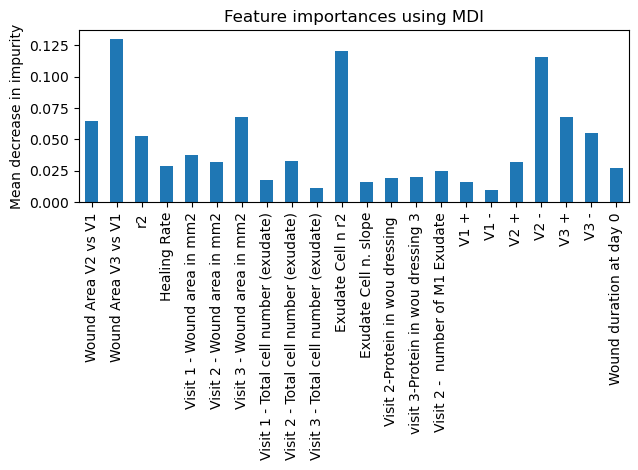

[[ 0.7975311   0.20246887]
 [ 0.1597377   0.8402623 ]
 [ 0.45768732  0.5423127 ]
 [ 0.49057204  0.50942796]
 [ 0.26431543  0.7356846 ]
 [ 0.83045447  0.16954553]
 [ 0.37504423  0.6249558 ]
 [ 0.81106496  0.18893501]
 [ 0.22393954  0.77606046]
 [ 1.0738103  -0.07381029]
 [ 0.73365986  0.2663401 ]
 [-0.01386416  1.0138642 ]
 [ 0.52556133  0.47443864]
 [ 0.22375369  0.7762463 ]
 [ 0.750835    0.249165  ]
 [ 0.1979549   0.8020451 ]]


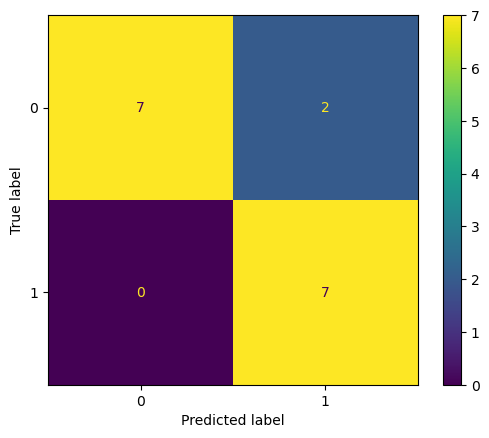

<Figure size 40000x12000 with 0 Axes>

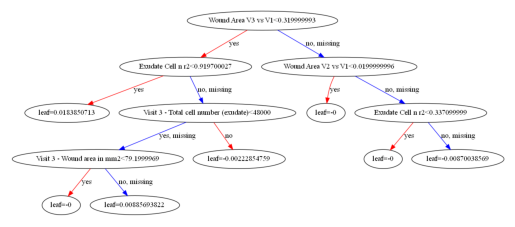

              precision    recall  f1-score   support

        Heal       1.00      1.00      1.00        36
         Not       1.00      1.00      1.00        27

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63

--------------------------------------------------------------------------------------------------


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model



W_tree=0
Treatment=pd.read_csv("../AD report/core_change_train.csv")
Treatment_test=pd.read_csv("../AD report/core_change_test.csv")


X_train=Treatment.iloc[:,1:]
y_train=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
y_test=Treatment_test.iloc[:,0]



#y_train = to_categorical(y_train)
#y_test = to_categorical(y_test)




R_state=random.randrange(1,100)
print("Random_state: ",R_state)
R_state=41


clf=XGBClassifier(
                  tree_method="hist",
                    objective="reg:pseudohubererror",
                  huber_slope=0.7,
                  eta=0.5,
                  subsample=0.8,
                  #max_depth=4,
                  colsample_bytree=0.5,
                  colsample_bylevel=0.8,
                 #colsample_bynode=0.7,
                  #reg_lambda=0.1,
                 reg_alpha=0.4,

                  
                   #random_state=R_state,
                  max_bin=2056,
                num_parallel_tree=25,

                
                  
                  
                  
    )

clf.fit(X_train, y_train)
#y_pred = clf.predict(X_test, iteration_range=(0, 75))
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 


class_names=["Heal","Not"]

print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names
importances = clf.feature_importances_

forest_importances = pd.Series(importances, index=names)
#forest_importances = pd.Series(importances)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

f = open("out.txt", "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()

y_pred = clf.predict(X_train)
y_pred = (y_pred > 0.5) 
print(classification_report(y_train,y_pred,output_dict=False,target_names=class_names))

print("--------------------------------------------------------------------------------------------------")

target = 'key'



from supertree import SuperTree
st = SuperTree(
    clf, 
    X_test, 
    y_test, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)
import pickle
file_name = "xgb_class1_2.pkl"
pickle.dump(clf, open(file_name, "wb"))